# AML23703 – Quantum Computing

## Tutorial 7: Deutsch’s Algorithm — Demonstrating Quantum Advantage

**Name:** Mythri M R  
    
**USN:** 1GA23AI027  

**Department:** Artificial Intelligence and Machine Learning  

**Semester:** VII  

**Course Code:** AML23703  

**Date:** 11-09-2026

## Aim

To understand Deutsch’s Algorithm and demonstrate how a quantum computer can determine whether a single-bit Boolean function is constant or balanced using only one quantum query.

## Theory

Deutsch’s Algorithm is one of the first quantum algorithms to demonstrate a quantum advantage over a classical deterministic method.

Consider a Boolean function:

**f(x) → {0, 1}**

where the input can be either 0 or 1.

There are four possible single-bit Boolean functions:

| Function | f(0) | f(1) | Type |
|---|---:|---:|---|
| f(x) = 0 | 0 | 0 | Constant |
| f(x) = 1 | 1 | 1 | Constant |
| f(x) = x | 0 | 1 | Balanced |
| f(x) = 1 − x | 1 | 0 | Balanced |

A function is **constant** if it gives the same output for both inputs.

A function is **balanced** if it gives different outputs for the two inputs.

Classically, both f(0) and f(1) may need to be checked.

Deutsch’s Algorithm uses quantum superposition and phase kickback to determine whether the function is constant or balanced using only **one query to the oracle**.

The final measurement gives:

**0 → Constant**

**1 → Balanced**

## Required Libraries

In [1]:
import sys
print(sys.executable)

C:\Users\MYTHRI  MR\AppData\Local\Python\pythoncore-3.14-64\python.exe


In [2]:
import subprocess
import sys

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "pylatexenc"
])

0

In [3]:
import pylatexenc
print("pylatexenc is installed!")

pylatexenc is installed!


In [4]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from IPython.display import display

simulator = AerSimulator()

# Exercise 1 – Easy: Constant Function f(x) = 0

## Objective

Implement the oracle for the constant function f(x) = 0 and verify that Deutsch’s Algorithm produces the output **0**, indicating a constant function.

## Theory

For the function f(x) = 0:

- f(0) = 0
- f(1) = 0

Both inputs produce the same output, so the function is **constant**.

For a constant function, Deutsch’s Algorithm should produce the measurement result:

**0 → Constant**

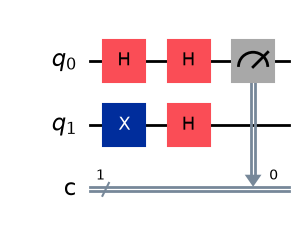

Measurement Result: {'0': 1024}


In [9]:
qc1 = QuantumCircuit(2, 1)

qc1.x(1)
qc1.h([0, 1])

# Oracle: f(x) = 0
# No gate needed

qc1.h(0)
qc1.measure(0, 0)

display(qc1.draw("mpl"))

counts1 = simulator.run(qc1, shots=1024).result().get_counts()

print("Measurement Result:", counts1)

## Output

The expected output is:

`{'0': 1024}`

The exact count may vary slightly if the circuit contains noise, but for the simulator the ideal result is 0.

## Observation

The measurement produced **0** for the constant function.

Therefore, Deutsch’s Algorithm correctly identifies f(x) = 0 as a **constant function**.

# Exercise 2 – Medium: Balanced Function f(x) = x

## Objective

Implement the oracle for the balanced function f(x) = x and verify that Deutsch’s Algorithm produces the output 1, indicating a balanced function.

## Theory

For the function f(x) = x:

- f(0) = 0
- f(1) = 1

The outputs are different for the two possible inputs, so the function is called **balanced**.

In Deutsch’s Algorithm, a CNOT gate is used as the oracle for f(x) = x.

The final measurement should give:

**0 → Constant**

**1 → Balanced**

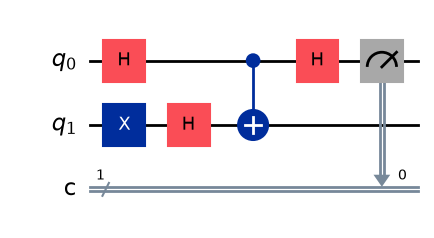

Measurement Result: {'1': 1024}


In [8]:
qc2 = QuantumCircuit(2, 1)

qc2.x(1)
qc2.h([0, 1])

# Oracle: f(x) = x
qc2.cx(0, 1)

qc2.h(0)
qc2.measure(0, 0)

display(qc2.draw("mpl"))

counts2 = simulator.run(qc2, shots=1024).result().get_counts()

print("Measurement Result:", counts2)

## Observation

The measurement produced **1** for the balanced function.

Therefore, Deutsch’s Algorithm correctly identifies f(x) = x as a **balanced function**.

The CNOT gate acts as the oracle and the final Hadamard gate converts the phase information into the measurable result 1.

## Exercise 3 Hard : Generic Oracle Selection

### Objective

To implement a general version of Deutsch's algorithm that can test different types of Boolean functions and determine whether each function is constant or balanced.

### Theory

There are four possible Boolean functions for a single input bit:

1. f(x) = 0 → Constant
2. f(x) = 1 → Constant
3. f(x) = x → Balanced
4. f(x) = NOT x → Balanced

The algorithm should give:

- Measurement 0 → Constant function
- Measurement 1 → Balanced function

A single quantum circuit can therefore be used with different oracle implementations to classify the function.

In [10]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from IPython.display import display

simulator = AerSimulator()

def deutsch(function_type):
    qc = QuantumCircuit(2, 1)

    # Prepare input and output qubits
    qc.x(1)
    qc.h([0, 1])

    # Oracle
    if function_type == "constant1":
        qc.x(1)

    elif function_type == "balanced_x":
        qc.cx(0, 1)

    elif function_type == "balanced_not":
        qc.x(1)
        qc.cx(0, 1)

    # Final Hadamard
    qc.h(0)

    # Measurement
    qc.measure(0, 0)

    return qc

In [11]:
functions = ["constant0", "constant1", "balanced_x", "balanced_not"]

for f in functions:
    qc = deutsch(f)
    counts = simulator.run(qc, shots=1024).result().get_counts()

    print(f, ":", counts)

constant0 : {'0': 1024}
constant1 : {'0': 1024}
balanced_x : {'1': 1024}
balanced_not : {'1': 1024}


Function: constant0


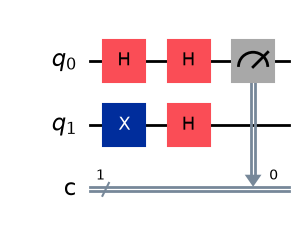

Function: constant1


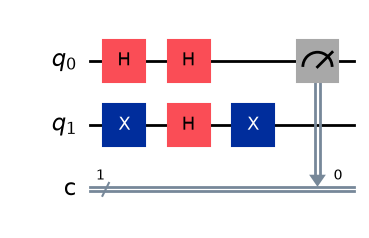

Function: balanced_x


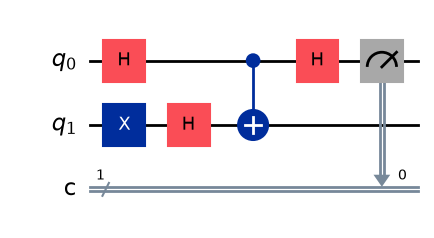

Function: balanced_not


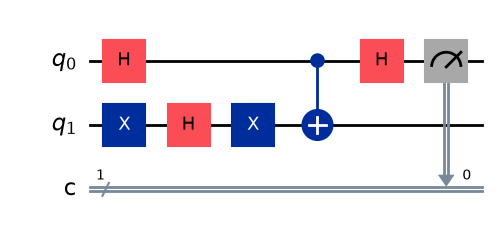

In [12]:
for f in functions:
    print("Function:", f)
    display(deutsch(f).draw("mpl"))

### Observation

The results show that both constant functions produce the measurement result 0, while both balanced functions produce the measurement result 1.

Therefore, Deutsch's algorithm successfully distinguishes constant functions from balanced functions using a single evaluation of the quantum oracle.

## Exercise 4: Real-World Application – Binary Classification

### Objective

To explain conceptually how phase kickback in Deutsch's algorithm can be related to a binary classification problem.

### Theory

In a binary classification problem, an input is assigned to one of two classes.

For example:

Input → Class

0 → Class A
1 → Class B

In Deutsch's algorithm, the oracle evaluates the function f(x). Instead of directly storing the function value in the output qubit, phase kickback transfers information about f(x) to the phase of the control qubit.

This phase information is then converted into a measurable result using the final Hadamard gate.

Conceptually:

Input
   ↓
Binary Classification
   ↓
Oracle f(x)
   ↓
Phase Kickback
   ↓
Final Hadamard
   ↓
Measurement
   ↓
Classification of Function

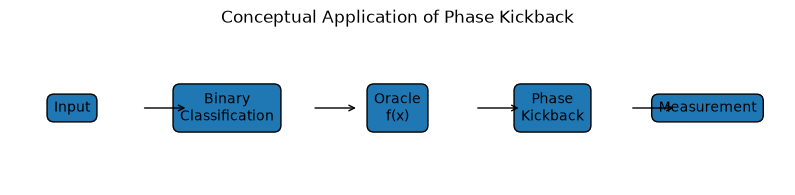

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 2))

ax.text(0.08, 0.5, "Input", ha="center", va="center",
        bbox=dict(boxstyle="round", pad=0.5))

ax.text(0.28, 0.5, "Binary\nClassification", ha="center", va="center",
        bbox=dict(boxstyle="round", pad=0.5))

ax.text(0.50, 0.5, "Oracle\nf(x)", ha="center", va="center",
        bbox=dict(boxstyle="round", pad=0.5))

ax.text(0.70, 0.5, "Phase\nKickback", ha="center", va="center",
        bbox=dict(boxstyle="round", pad=0.5))

ax.text(0.90, 0.5, "Measurement", ha="center", va="center",
        bbox=dict(boxstyle="round", pad=0.5))

for x in [0.17, 0.39, 0.60, 0.80]:
    ax.annotate("", xy=(x+0.06, 0.5), xytext=(x, 0.5),
                arrowprops=dict(arrowstyle="->"))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

plt.title("Conceptual Application of Phase Kickback")
plt.show()

### Observation

The diagram shows how a binary classification problem can conceptually be connected to Deutsch's algorithm. The oracle represents the classification function, while phase kickback transfers information about the function into the phase of the control qubit. The final measurement reveals information about whether the function is constant or balanced.

## Excercise 5 - Challenge: Effect of an Imperfect Hadamard Gate

### Objective

To introduce a small deliberate error into a Hadamard operation and study how the measurement reliability of Deutsch's algorithm is affected.

### Theory

In an ideal circuit, the Hadamard gate produces the required quantum superposition and interference.

In a real quantum computer, gates may not be perfectly implemented. A small error in the Hadamard operation can change the quantum state.

As a result, the measurement may no longer give the expected result with 100% probability.

The measurement counts can be represented using a bar chart to show the degradation in reliability.

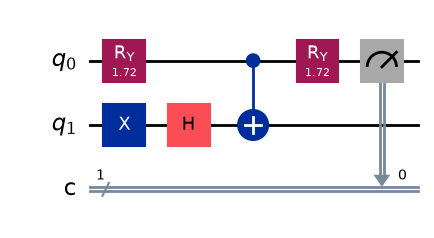

Measurement Result: {'0': 1024}


In [18]:
import numpy as np
import matplotlib.pyplot as plt

qc_error = QuantumCircuit(2, 1)

qc_error.x(1)

# Imperfect Hadamard on qubit 0
qc_error.ry(np.pi / 2 + 0.15, 0)

# Hadamard on output qubit
qc_error.h(1)

# Balanced oracle f(x) = x
qc_error.cx(0, 1)

# Final imperfect Hadamard
qc_error.ry(np.pi / 2 + 0.15, 0)

qc_error.measure(0, 0)

display(qc_error.draw("mpl"))

counts_error = simulator.run(
    qc_error,
    shots=1024
).result().get_counts()

print("Measurement Result:", counts_error)

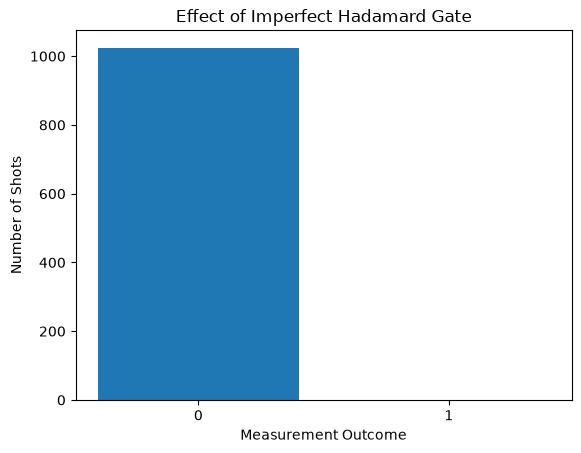

In [19]:
labels = ["0", "1"]

values = [
    counts_error.get("0", 0),
    counts_error.get("1", 0)
]

plt.bar(labels, values)
plt.xlabel("Measurement Outcome")
plt.ylabel("Number of Shots")
plt.title("Effect of Imperfect Hadamard Gate")
plt.show()

### Observation

The imperfect Hadamard gates introduce a small error into the quantum circuit. Therefore, the measurement is no longer perfectly reliable.

Instead of obtaining only the expected result 1, some measurements may produce 0 as well.

The bar chart shows how the gate error affects the reliability of the measurement outcome.

## Conclusion

Deutsch's algorithm demonstrates how quantum computing can solve a problem with fewer function evaluations than a classical approach.

In this tutorial, we implemented Deutsch's algorithm for both constant and balanced Boolean functions. The measurement of the first qubit allowed us to distinguish between the two types:

- Measurement 0 → Constant function
- Measurement 1 → Balanced function

We also tested different oracle functions and studied how a small gate error can affect the measurement results.

The tutorial demonstrates the importance of quantum superposition, interference, and quantum oracles in achieving quantum computational advantage.

## Reflection Questions

### 1. Why is Deutsch's algorithm historically significant despite its limited practical use?

Deutsch's algorithm is historically significant because it was one of the first algorithms to demonstrate that a quantum computer could solve a specific problem using fewer queries than a classical deterministic computer.

Although the problem itself has limited practical importance, the algorithm demonstrated the potential of quantum computation and introduced important ideas such as superposition, quantum interference, and phase kickback.

### 2. How does phase kickback allow information about f(x) to appear in the control qubit's phase?

Phase kickback occurs when the oracle acts on the output qubit prepared in the state |->.

Instead of changing only the output qubit, the value of f(x) changes the phase of the control qubit.

The final Hadamard gate converts this phase information into a measurable state. Therefore, measuring the control qubit reveals whether the function is constant or balanced.